# LISA BHB & WDB Instance Segmentation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

%matplotlib inline

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from bbhx.response.fastfdresponse import LISATDIResponse
from bbhx.likelihood import Likelihood, HeterodynedLikelihood
from bbhx.utils.constants import *
from bbhx.utils.transform import *

from lisatools.sensitivity import get_sensitivity

import sys

np.random.seed(111222)

No CuPy


## Step 1: The BHB Chirp Data

### 1a.) Plotting the Chirp Function

In [8]:
arr = np.array([-20, 1, np.inf, -np.inf])
arr = np.abs(arr)
print(min(arr))

1.0


1.0121137516259524
-0.446746148948589


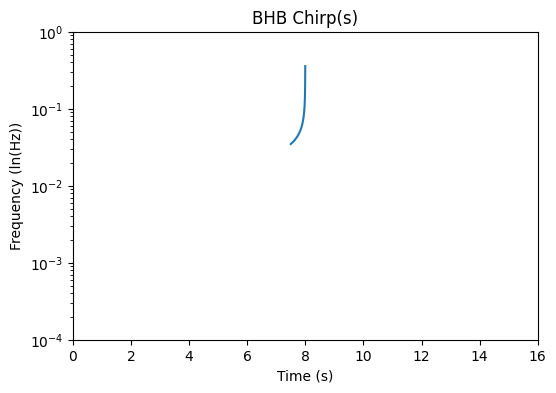

In [2]:
G = 6.67e-11  # im too lazy to think of the units and write them
c = 3e8  # m/s
pi = np.pi
MSun = 1.989E30

def BHBFreq(t, M, t_c):  # M has to be in kg, t must be in seconds to get output units of Hz
    return ((8 * pi) ** (8/3) / 5 * (G * M / c**3)**(5/3) * (t_c - t))**(-3/8)

t_c = 15
M = 1e31
ts = np.linspace(14.5, 15, 1000)

#plt.rcParams['figure.dpi'] = 150
dpi = 10
px = 1/dpi
pixScale = 1

t_c2 = 8
M2 = 2e36
ts2 = np.linspace(7.5, 7.999, 1000)  # if we make the last observation time = 9, we get an infinite number for the highest value
freqs2 = BHBFreq(ts2, M2, t_c2)

print(max(np.log10(freqs2)) - min(np.log10(freqs2)))
print(max(np.log10(freqs2)))

plt.figure(figsize = (6.0 / pixScale, 4.0 / pixScale), dpi = 100 * pixScale)
plt.xlim(0, 16)
plt.ylim(10**(-4), 10**0)
#plt.plot(ts, BHBFreq(ts, M, t_c))
plt.plot(ts2, BHBFreq(ts2, M2, t_c2))
plt.semilogy()
plt.title(rf'BHB Chirp(s)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (ln(Hz))')
#plt.yticks([])  # remove axis numbers
#plt.xticks([])  # remove axis numbers
#plt.tick_params(axis='both', which='both', bottom = False, top = False, left = False, right = False)  # remove tick marks
plt.savefig('BHB Chirp', dpi = 10, bbox_inches = 'tight')

Playing with the parameters a bit, we can see that t_c determines the x-position of the curve, and M determines the y-position. However, the shape of the curve and the range of values are independent of these parameters, as long as the range of the domain of the curve (i.e. min to max time) stays the same.

### 1b.) Strain vs. Frequency Data

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

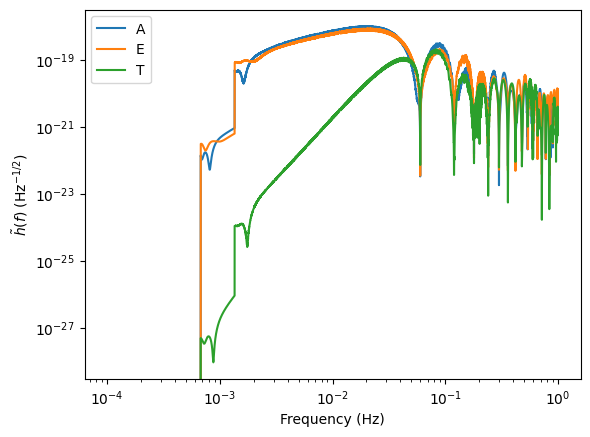

In [3]:
# --------------------------------- code copied from BBHx tutorial -----------------------------------
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))
# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e4  # original: 1e6
m2 = 5e3  # original: 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc 
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle 
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam, 
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0] 

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")
# ------------------------------------- end of copied code --------------------------------------------

#print([len(x) for x in [freq_new, wave[0], wave[1], wave[2]]])  # same length, so why does the waveform in plt.loglog() not extend to 10^0 like freq_new does? actually, the last values seem to be 0, which can't actually be plotted on a log scale since 0 is anything^(-infinity). So I guess that's why.
#print(max([x.imag for x in wave[0]]))
#print(wave[0][5209])  # found index of max imag with np.argmax

#print(min([x.real - x.imag for x in wave[0]]))
#print(wave[0][5201])  # np.argmin
#print(min(x.real for x in wave[0]))


The strain here is complex, but only the real component is plotted. Interestingly, when using plt.plot with complex values, a warning is administered saying the imag component is discarded, but this warning is absent when using plt.loglog, which is just a simple wrapper of plt.plot. However, the maximum imag component is about 4.3E-17 whereas the real components are typically much larger (the min difference of x.real - x.imag is -6.07E-17).

Also, the frequency extends to 1 (which is 10^0), and the frequency and strain arrays have the same length, but the graph seems to end at like, 10^(-.8). That's probably because the y-axis is on a log scale and the strain values near the higher frequencies get close to 0 and eventually negative, which can't be plotted on a log scale (negative is impossible and for 0 you'd need 10^(-infinity)).

### 1c.) Strain(Frequency, Time) Matrix
The strain correlates with the amplitude of the gravitational wave. Our goal is to extract the strain vs. frequency data and store it in a 2d matrix where the rows (y-values) are frequency and columns (x-values) are time, and the strain values will determine the heatmap color for the final image. The strain depends on the frequency. The A, E, and T components are linear combinations of X, Y, and Z from the detector. According to Ira, the T component is only sensitive at higher frequencies. Also according to Ira, we can just say the amplitude is $\sqrt{A^2 + E^2}$.

YOLO26's optimal image size is 640x640 pixels, so let's use that.

Min Freq: 1.025e+00, Max Freq: 8.703e+00
Min log10Freq: 1.073e-02, Max log10Freq: 9.396e-01
Lengths: waveA: 10000, waveE: 10000, freqs: 10000, log10Freqs: 10000
0.0
Frequency: 1.03e+00; FrequencyPixel: 0; Time: 4.70e+00; TimePixel: 195; Intensity: 4.64e-21
0.008325932758090829
Frequency: 1.04e+00; FrequencyPixel: 2; Time: 4.71e+00; TimePixel: 195; Intensity: 1.60e-20
0.017100554500611778
Frequency: 1.07e+00; FrequencyPixel: 4; Time: 4.73e+00; TimePixel: 196; Intensity: 9.67e-21
0.026374993824356777
Frequency: 1.09e+00; FrequencyPixel: 7; Time: 4.74e+00; TimePixel: 196; Intensity: 6.58e-21
0.03620964938603413
Frequency: 1.11e+00; FrequencyPixel: 9; Time: 4.76e+00; TimePixel: 197; Intensity: 1.20e-20
0.046676575861250146
Frequency: 1.14e+00; FrequencyPixel: 12; Time: 4.77e+00; TimePixel: 198; Intensity: 4.46e-22
0.05786269064874312
Frequency: 1.17e+00; FrequencyPixel: 15; Time: 4.79e+00; TimePixel: 198; Intensity: 1.01e-20
0.06987416530791357
Frequency: 1.20e+00; FrequencyPixel: 18; Time

/var/folders/d3/lrkm9wrd7dj3b35pydsk37v40000gp/T/ipykernel_98413/2242556604.py:89: RuntimeWarning: invalid value encountered in divide
  smoothedImage = VV/WW


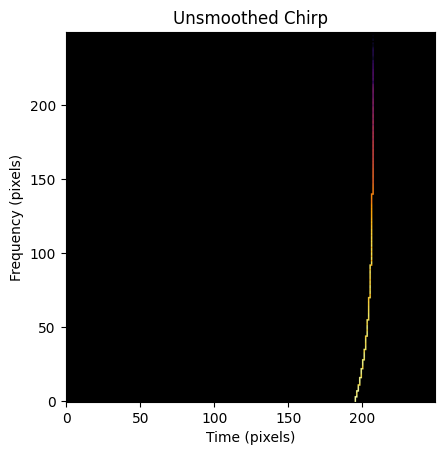

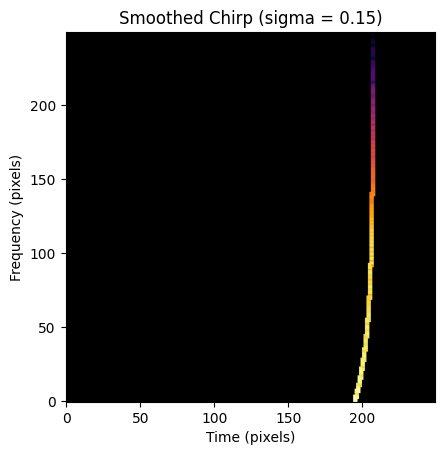

In [4]:
from scipy.ndimage import gaussian_filter

np.set_printoptions(threshold=sys.maxsize)

WDMImage = np.full((250, 250), np.nan)

# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e4
m2 = 5e3
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc 
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle 
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# ------------------------------------------------------------------------------
t_c = 5
M = (m1 * MSun * m2 * MSun)**(3/5) / (m1 * MSun + m2 * MSun)**(1/5)
ts = np.linspace(4.7, 4.999, 10000)
freqs = BHBFreq(ts, M, t_c)
log10Freqs = np.log10(freqs)

#plt.plot(ts, freqs)
#plt.semilogy()
#plt.figure()
#plt.plot(ts, log10Freqs)

print(f'Min Freq: {min(freqs):.3e}, Max Freq: {max(freqs):.3e}')
print(f'Min log10Freq: {min(log10Freqs):.3e}, Max log10Freq: {max(log10Freqs):.3e}')
#print(freqs)
#print()      
#print(log10Freqs)

# ------------------------------------------------------------------------------


# frequencies to interpolate to: freqs from above
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waves = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam, 
                          beta, psi, t_ref, freqs=freqs,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]
waveA = waves[0]
waveE = waves[1]

print(f'Lengths: waveA: {len(waveA)}, waveE: {len(waveE)}, freqs: {len(freqs)}, log10Freqs: {len(log10Freqs)}')

maxTime = 6  # s
maxLog10Freq = max(log10Freqs)  # log10(Hz)
minLog10Freq = min(log10Freqs)  # log10(Hz)
#minLog10Freq = 3E-1
#maxLog10Freq = -1E-3
maxFreq = 4E0  # Hz

m, n = WDMImage.shape

# WDMImage[row][col] = intensity(row)
for idx, t in enumerate(ts):
    timePixelPos = int(np.floor(t / maxTime * (n - 1)))  # we're doing n - 1 and m - 1 because we want t = maxTime to correspond to index 639 (the 640th pixel)
    freqPixelPos = int(np.floor((log10Freqs[idx] - minLog10Freq) / (maxLog10Freq - minLog10Freq) * (m - 1)))

    intensity = np.sqrt(np.abs(waveA[idx])**2 + np.abs(waveE[idx])**2)
    
    #print((freqPixelPos, timePixelPos))
    WDMImage[freqPixelPos][timePixelPos] = np.log10(intensity)

    if idx % 500 == 0:
        print(log10Freqs[idx] - minLog10Freq)
        print(f'Frequency: {freqs[idx]:.2e}; FrequencyPixel: {freqPixelPos}; Time: {t:.2e}; TimePixel: {timePixelPos}; Intensity: {intensity:.2e}')

cmap = plt.get_cmap('inferno').copy()
cmap.set_bad(color='black')  # 'k' can also be used for black

# Making a smooth image: https://stackoverflow.com/questions/18697532/gaussian-filtering-a-image-with-nan-in-python
sigma = 0.15
V = WDMImage.copy()
V[np.isnan(WDMImage)] = 0
VV = gaussian_filter(V, sigma = sigma)

W = 0 * WDMImage.copy() + 1
W[np.isnan(WDMImage)] = 0
WW = gaussian_filter(W, sigma = sigma)

smoothedImage = VV/WW
# -------- end of copied code ---------

plt.figure()
plt.title('Unsmoothed Chirp')
plt.imshow(WDMImage, origin = 'lower', cmap = cmap)
plt.xlabel('Time (pixels)')
plt.ylabel('Frequency (pixels)')
plt.savefig('unsmoothedChirp.png', dpi = 600)

plt.figure()
plt.title(f'Smoothed Chirp (sigma = {sigma})')
plt.xlabel('Time (pixels)')
plt.ylabel('Frequency (pixels)')
plt.imshow(smoothedImage, origin = 'lower', cmap = cmap)
plt.savefig('smoothedChirp.png')

#print(WDMImage[WDMImage > 0])
#print(smoothedImage[smoothedImage < 0])


### Placing in an Image
We need to place the graph in an image and also output a segmentation map (mask) to be able to train YOLO26.

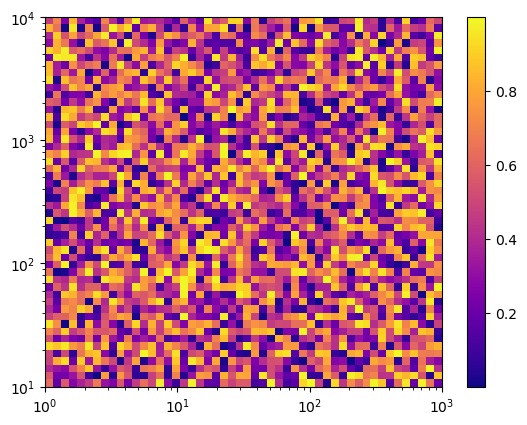

In [22]:
# Create regular image dimensions
rows, cols = 50, 50
data = np.random.rand(rows, cols)

# Define logarithmic pixel borders for the axes
x_coords = np.logspace(0, 3, cols + 1)  # X-axis spans from 10^0 to 10^3
y_coords = np.logspace(1, 4, rows + 1)  # Y-axis spans from 10^1 to 10^4

fig, ax = plt.subplots()

# Map the grid onto log space
ax.set_xscale('log')
ax.set_yscale('log')

# Use pcolormesh to physically stretch the image across the log grid
mesh = ax.pcolormesh(x_coords, y_coords, data, cmap='plasma')
fig.colorbar(mesh)



## Step 2: Training YOLO26

In [3]:
# Load a pretrained YOLO model
model = YOLO("yolo26m-seg.pt")

# Perform object detection on an image
results = model("https://ultralytics.com/images/bus.jpg")  # Great results
#results = model("IraExampleImage.png")  # nothing detected (expected)

# Visualize the results
for result in results:
    result.show()


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/jxgeorge/LISA Project/bus.jpg: 640x480 4 persons, 1 bus, 203.3ms
Speed: 1.7ms preprocess, 203.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
